<a href="https://colab.research.google.com/github/KRUTHIKA-8/credit-card-default-prediction/blob/main/credit_card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# ===============================
# 1 Import Libraries
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [37]:
df = pd.read_csv("/content/UCI_Credit_Card.csv")

print(df.head())
print(df.shape)

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

In [38]:
df = df.drop("ID", axis=1)
print(df.isnull().sum())

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


In [39]:
df["SEX"] = df["SEX"].astype("category")
df["EDUCATION"] = df["EDUCATION"].astype("category")
df["MARRIAGE"] = df["MARRIAGE"].astype("category")

df = pd.get_dummies(df, drop_first=True)
scaler = StandardScaler()

df["LIMIT_BAL"] = scaler.fit_transform(df[["LIMIT_BAL"]])

In [40]:
X = df.drop("default.payment.next.month", axis=1)
y = df["default.payment.next.month"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: default.payment.next.month
0    18677
1     5323
Name: count, dtype: int64
After SMOTE: default.payment.next.month
0    18677
1    18677
Name: count, dtype: int64


In [42]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

In [44]:
xgb = XGBClassifier(eval_metric='logloss')

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)

In [45]:
def evaluate_model(y_test, y_pred):

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)

    print("Precision:", precision)
    print("Recall:", recall)
    print("ROC-AUC:", roc)
    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

In [46]:
print("Logistic Regression Results")

evaluate_model(y_test, y_pred_lr)

Logistic Regression Results
Precision: 0.3605263157894737
Recall: 0.6260472201066261
ROC-AUC: 0.6574870194836523

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.69      0.77      4687
           1       0.36      0.63      0.46      1313

    accuracy                           0.68      6000
   macro avg       0.61      0.66      0.61      6000
weighted avg       0.76      0.68      0.70      6000



In [47]:
print("Random Forest Results")

evaluate_model(y_test, y_pred_rf)

Random Forest Results
Precision: 0.579107505070994
Recall: 0.43488194973343486
ROC-AUC: 0.6731695859185629

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      4687
           1       0.58      0.43      0.50      1313

    accuracy                           0.81      6000
   macro avg       0.72      0.67      0.69      6000
weighted avg       0.79      0.81      0.80      6000



In [48]:
print("XGBoost Results")

evaluate_model(y_test, y_pred_xgb)

XGBoost Results
Precision: 0.5881057268722467
Recall: 0.4067022086824067
ROC-AUC: 0.6634535152650352

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.92      0.88      4687
           1       0.59      0.41      0.48      1313

    accuracy                           0.81      6000
   macro avg       0.72      0.66      0.68      6000
weighted avg       0.79      0.81      0.79      6000



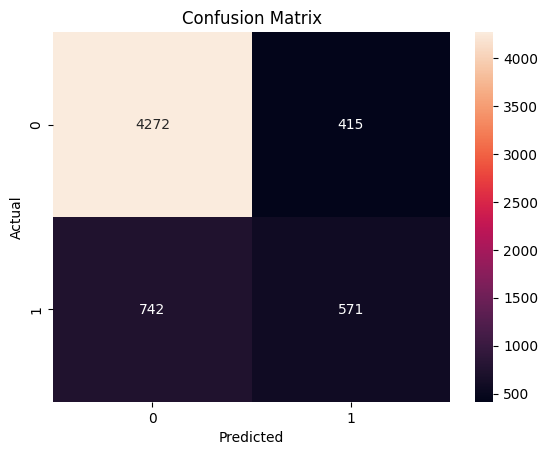

In [49]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

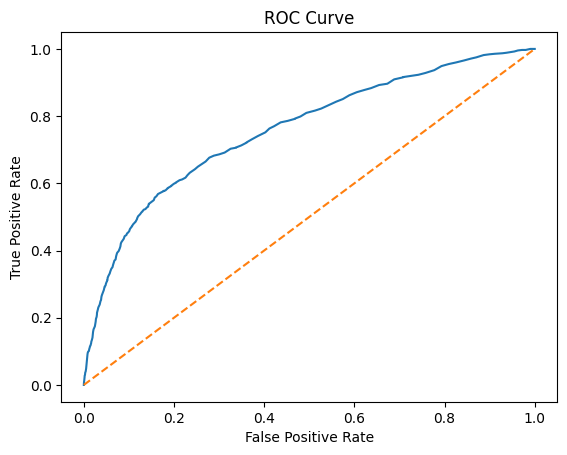

In [50]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

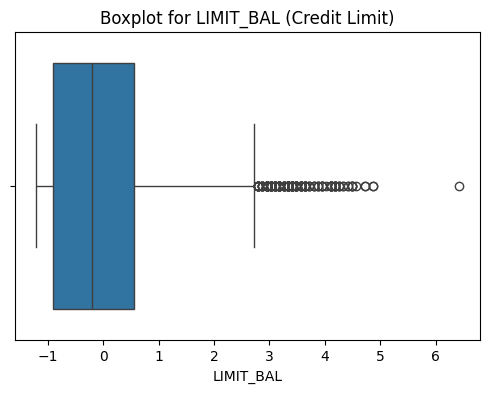

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=df["LIMIT_BAL"])

plt.title("Boxplot for LIMIT_BAL (Credit Limit)")
plt.show()


In [52]:
# Calculate Q1 and Q3
Q1 = df["LIMIT_BAL"].quantile(0.25)
Q3 = df["LIMIT_BAL"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Remove outliers
df = df[(df["LIMIT_BAL"] >= lower_limit) & (df["LIMIT_BAL"] <= upper_limit)]

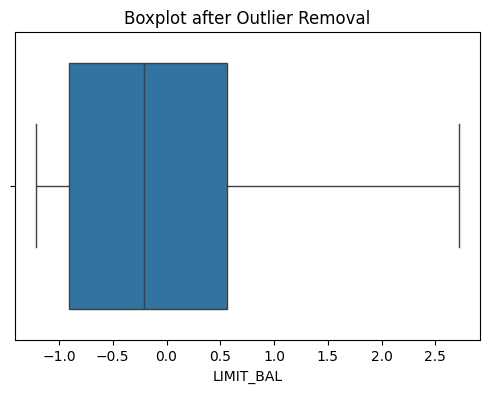

In [53]:
#ploting the boxplot to check the outliers after the IQR
plt.figure(figsize=(6,4))
sns.boxplot(x=df["LIMIT_BAL"])
plt.title("Boxplot after Outlier Removal")
plt.show()